# **CAM and Object Detection**
Adele Chen, a332chen@uwaterloo.ca 

Jenny Zhang, j2447zha@uwaterloo.ca

Clara Goh, EMAIL HERE

## Abstract

This project explores weakly supervised object localization by combining class activation mapping (CAM) with image-level classification. Using the PASCAL VOC dataset, which provides images with bounding-box annotations, we construct a binary classification task for the object class 'cat'. The CNN **CNN HERE** was trained using only image-level labels, where positive samples contain at least one instance of the target object and negative samples contain none. After training, GradCAM was applied to generate spatial heatmaps that highlight regions contributing most to the predicted class. These heatmaps are upsampled and overlaid on the original images to visually assess whether the network has learned meaningful object localization cues despite the absence of explicit bounding-box supervision during training.

To derive approximate object locations, **the CAM heatmaps are post-processed by applying thresholding and extracting the largest connected component, from which a centroid and optional bounding rectangle are computed as weak localization estimates**. These predictions are evaluated against the ground-truth annotations in the PASCAL VOC dataset using multiple metrics, including classification accuracy, whether the predicted center lies within a ground-truth bounding box, the distance between predicted and true object centers, and intersection-over-union (IoU) between predicted and annotated boxes. 

This framework aims to assess the feasibility of using weak supervision for object detection and tracking tasks, providing insight into how well spatial information can emerge from purely image-level training signals. **RESULT**.

## Team Members and Contributions

List of contributions here

## Code Libraries

Then following external code libraries were essential for our project:
- Numpy
- Matplotlib
- Torch and Torchvision

In addition, we wrote our own code libraries in order to better organize this jupyter notebook. The following libraries were created and are located in the `mylibs` folder.
- List and description of each library we wrote

# Set Up - Import Libraries

In [19]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Subset

from mylibs.datasets import VOCCatBinaryDataset
from mylibs.transforms import get_image_transform
from mylibs.train_cat_classifier import CatClassifier
from mylibs.trainer import Trainer
from mylibs.gradcam import GradCAM
from mylibs.gradcam_utils import (
    cam_to_bbox_and_center,
    cam_to_binary_mask,
    visualize_cam_bbox,
)
from mylibs.eval import (
    eval_collate_fn,
    build_model,
    evaluate,
)
from mylibs.utils import get_balanced_indices, visualize_cat_images, unnormalize

# Config

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

DATA_ROOT = "./data"
CHECKPOINT_PATH = "checkpoints/best_model.pth"

BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4

Using device: cpu


# Build Datasets

In [3]:
transform = get_image_transform()

# MAKE SURE YOU SET "download = FALSE" AFTER THE DATASET IS LOADED ON YOUR COMPUTER ON THE FIRST RUN OF THIS CELL (creates "datasets" folder)
train_dataset = VOCCatBinaryDataset(
    root=DATA_ROOT,
    year="2012",
    image_set="train",
    transform=transform,
    download=False,
)

val_dataset = VOCCatBinaryDataset(
    root=DATA_ROOT,
    year="2012",
    image_set="val",
    transform=transform,
    download=False,
)

# Ensure there is a balanced number of cat vs no cat images in the dataset
indices = get_balanced_indices(train_dataset, max_per_class=5)
balanced_train_dataset = Subset(train_dataset, indices)

indices = get_balanced_indices(val_dataset, max_per_class=5)
balanced_val_dataset = Subset(val_dataset, indices)

# Inspect One Sample

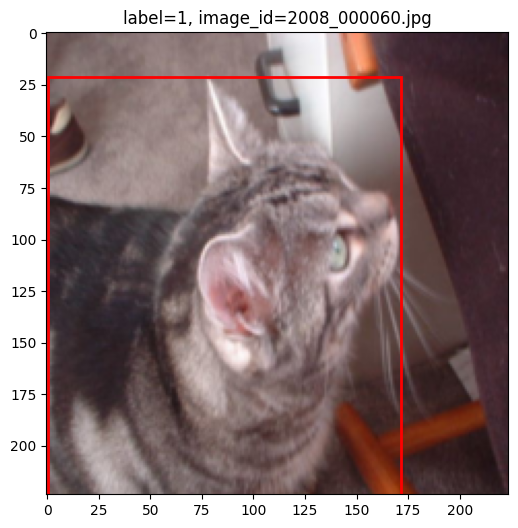

In [ ]:
# Visualize one cat samples from the training dataset
visualize_cat_images(balanced_train_dataset, 1)

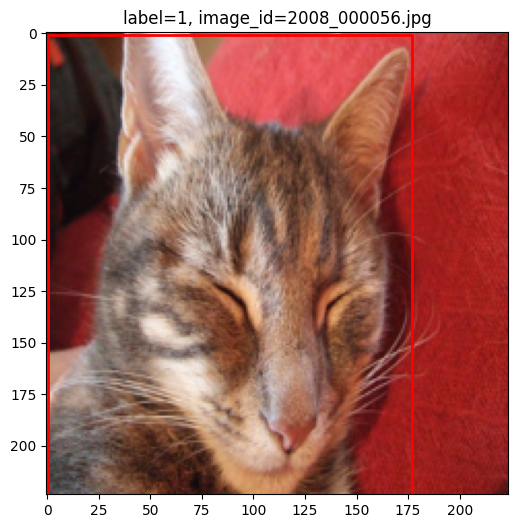

In [8]:
# Visualize a cat sample from the validation dataset
visualize_cat_images(balanced_val_dataset, 1)

# Build Model

The model's implementation is mostly done in the file `train_cat_classifier` which can be found in `mylibs`. The unerlying model that we're using is Resnet18. We decided to use Resnet18 rather than Resnet34 because we prioritize speed and efficiency for our model. Given that our classifier only performs a binary classification, we didn't require the additional complexity that Resnet34 would add. In addition, Resnet34 is more prone to overfitting on more limited datasets due to its ability to learn more complex patterns. Resnet18 would be safer in regards to overfitting to use on our dataset, which is relatively quite small.

In [ ]:
# Already pretrained
untrained_model = CatClassifier()

Now let's run our untrained model on a singular sample image to see how it does.

tensor([[0.]])


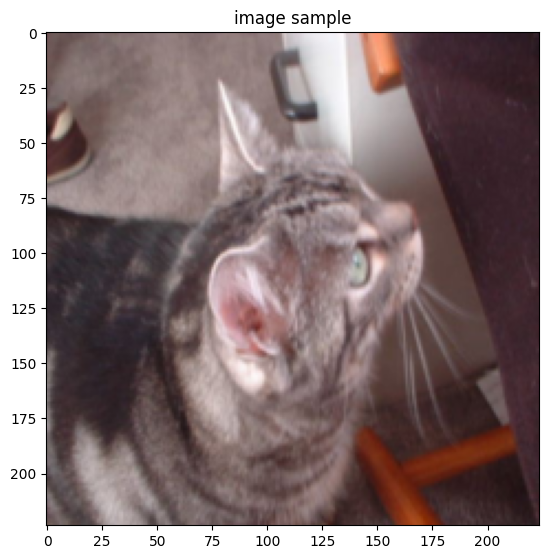

In [22]:
untrained_model.eval()
sample_img, sample_label, sample_target = balanced_train_dataset[0]


# Resnet18 works best on 3 x 224 x 224 images, which is what the dataset consists of
untrained_output = untrained_model.predict(sample_img[None])
print(untrained_output)

sample_img = unnormalize(sample_img)
image_np = sample_img.permute(1, 2, 0).numpy()

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(1,2,1)
plt.title('image sample')
ax.imshow(image_np)

# Train the Classifier

The implementation of our training loop can be found in `mylibs` under the file `trainer`. In addition to other arguments such as the training and validation datasets, we also need to pass in the criterion (ie loss function) and optimizer we would like to use.

For this classifier, we decided to use a `BCEWithLogits` for the criterion, because this loss function would be able to directly learn $P(cat)$, which is all we need as this is a binary classifier.

For the optimizer, we decided to use an ADAM optimizer with a learning rate of `1e-4`. EXPALIN WHY HERE

# Load the Best Checkpoint

# Run Evaluation

# Print Metrics

# Visualize One Grad-CAM Sample

# Visualize a Few Examples

# Conclusion

2-3 paragraph conclusion here